--- PUNTO 4.1: Pipeline de Realce de Esqueleto ---


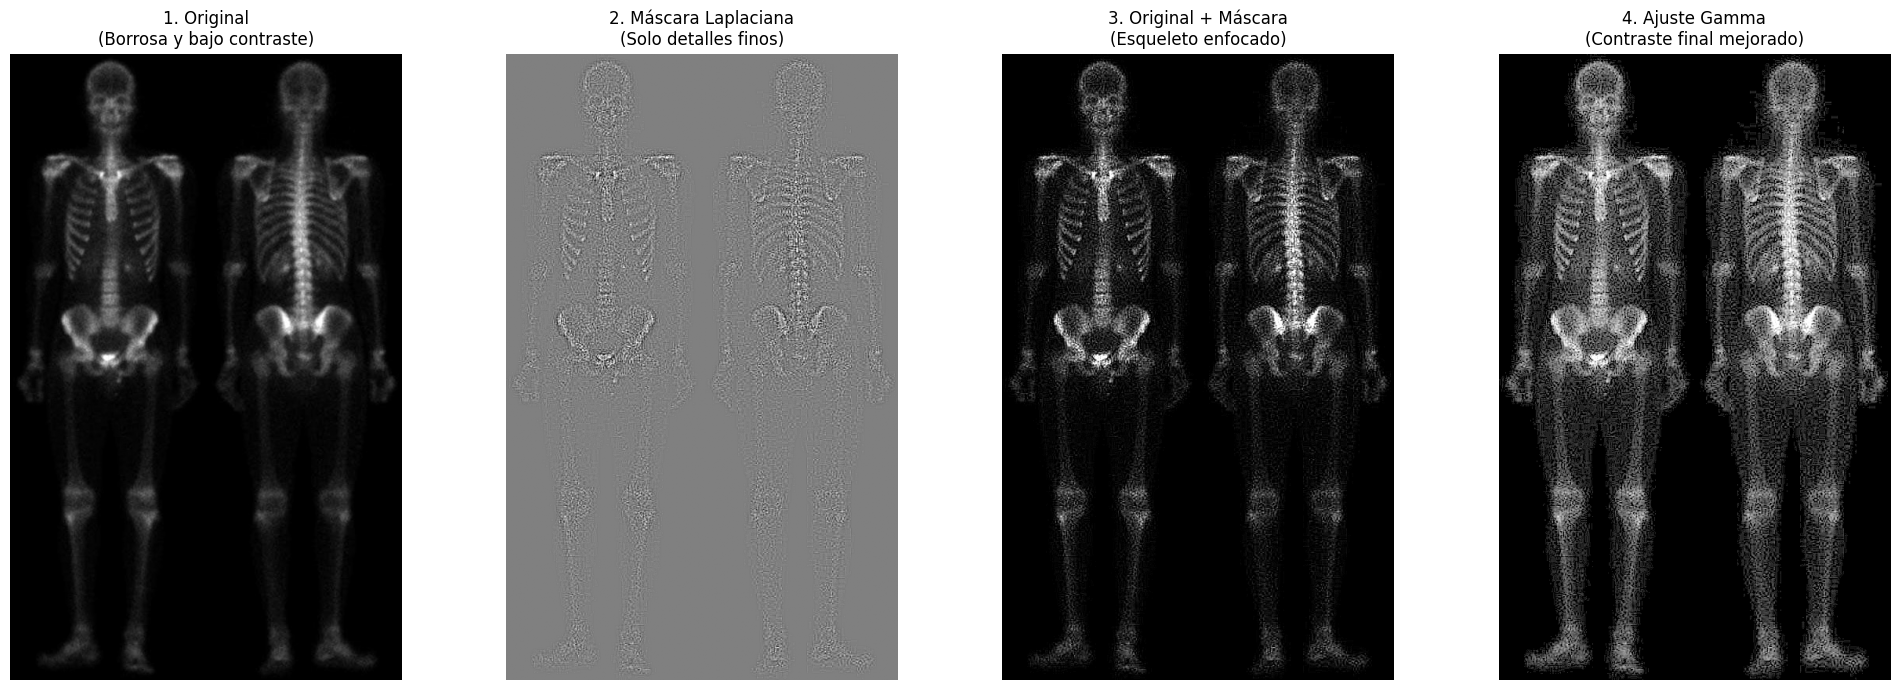

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargamos la imagen
img = cv2.imread('esqueleto.tif', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("❌ Error: No se encuentra 'esqueleto.tif'.")
else:
    print("--- PUNTO 4.1: Pipeline de Realce de Esqueleto ---")
    
    # 1. Pasamos a float32 para poder tener valores negativos al restar y sumar
    f = img.astype(np.float32)
    
    # 2. LAPLACIANO (Extracción de bordes)
    # Usamos un filtro agresivo que incluya las diagonales para captar todos los detalles de los huesos
    kernel_laplace = np.array([[-1, -1, -1],
                               [-1,  8, -1],
                               [-1, -1, -1]], dtype=np.float32)
    
    bordes = cv2.filter2D(f, -1, kernel_laplace)
    
    # 3. SHARPENING (Enfoque sumando bordes a la original)
    esq_enfocado = f + bordes
    
    # 4. TRANSFORMACIÓN GAMMA (Mejora de contraste)
    # Como la imagen enfocada sigue siendo un poco oscura, le aplicamos un gamma < 1 
    # para expandir los grises claros y que el esqueleto "brille" más.
    gamma = 0.5
    esq_final = np.power(np.clip(esq_enfocado, 0, 255) / 255.0, gamma) * 255.0
    
    # --- Preparamos todo para graficar (recortando a 0-255 y pasando a uint8) ---
    esq_final = np.clip(esq_final, 0, 255).astype(np.uint8)
    esq_enfocado_vis = np.clip(esq_enfocado, 0, 255).astype(np.uint8)
    
    # A los bordes les sumamos 128 solo para que el fondo se vea gris y los detalles resalten
    bordes_visibles = np.clip(bordes + 128, 0, 255).astype(np.uint8)

    # --- Graficamos el paso a paso ---
    plt.figure(figsize=(20, 7))
    
    plt.subplot(1, 4, 1)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title('1. Original\n(Borrosa y bajo contraste)')
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.imshow(bordes_visibles, cmap='gray', vmin=0, vmax=255)
    plt.title('2. Máscara Laplaciana\n(Solo detalles finos)')
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    plt.imshow(esq_enfocado_vis, cmap='gray', vmin=0, vmax=255)
    plt.title('3. Original + Máscara\n(Esqueleto enfocado)')
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.imshow(esq_final, cmap='gray', vmin=0, vmax=255)
    plt.title('4. Ajuste Gamma\n(Contraste final mejorado)')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

--- PUNTO 4.2: Comparación Bilateral vs Gaussiano ---


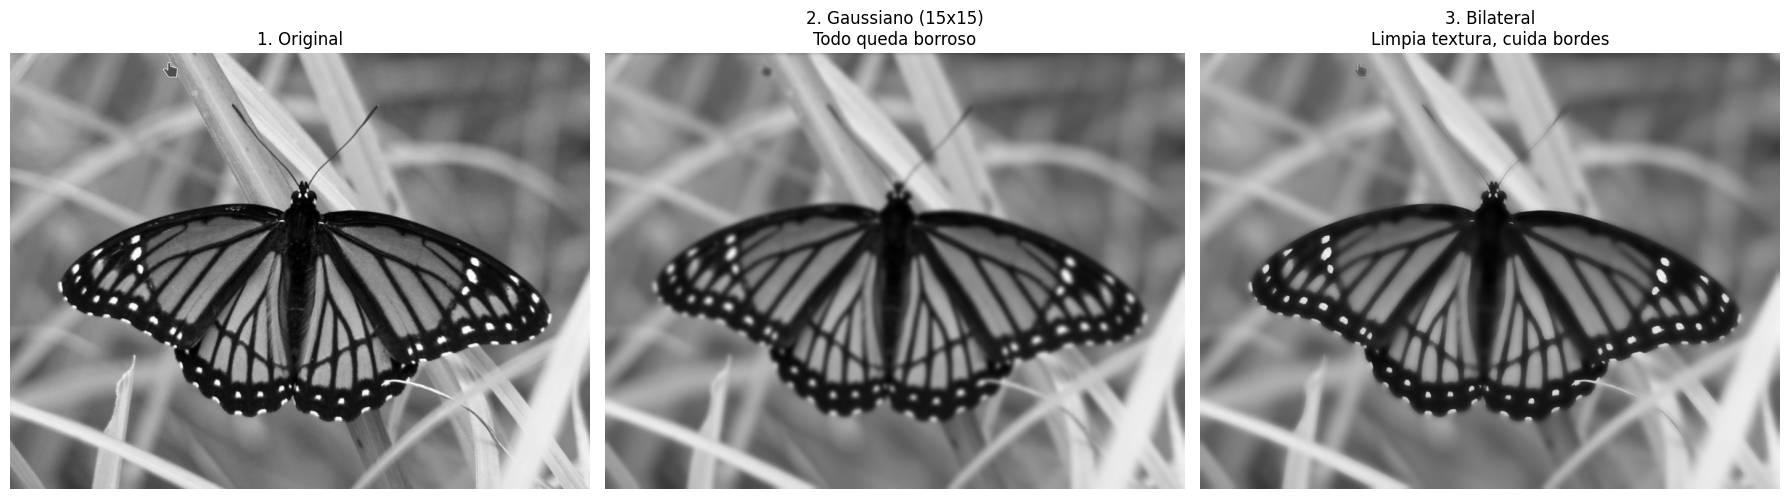


--- PUNTO 4.3: Análisis de Perfil de Grises ---


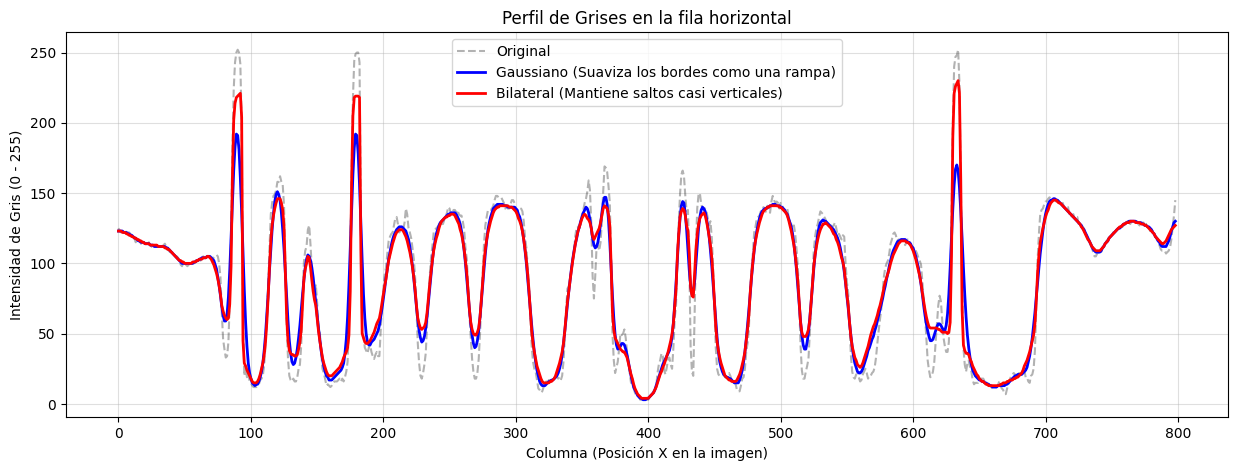

In [6]:
print("--- PUNTO 4.2: Comparación Bilateral vs Gaussiano ---")

img_path = 'lapices02.jpg'
img_path = 'mariposa02.png'
#img_path = 'flores02.jpg'

img_test = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img_test is None:
    print(f"❌ Error: No se encuentra '{img_path}'.")
else:   
    #1.Filtro gaussiano
    # Le damos un tamaño de 15x15 para que el desenfoque sea bien notorio
    img_gauss = cv2.GaussianBlur(img_test, (15, 15), 0)

    #2.Filtro bilateral
    img_bilateral = cv2.bilateralFilter(img_test, d=15, sigmaColor=80, sigmaSpace=80)

    #Visualizacion de las imagenes
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img_test, cmap='gray', vmin=0, vmax=255)
    plt.title("1. Original")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(img_gauss, cmap='gray', vmin=0, vmax=255)
    plt.title("2. Gaussiano (15x15)\nTodo queda borroso")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(img_bilateral, cmap='gray', vmin=0, vmax=255)
    plt.title("3. Bilateral\nLimpia textura, cuida bordes")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\n--- PUNTO 4.3: Análisis de Perfil de Grises ---")

    # Extraemos esos píxeles como si fueran un arreglo de 1D
    fila = img_test.shape[0] // 2
    perfil_original = img_test[fila, :]
    perfil_gauss = img_gauss[fila, :]
    perfil_bilateral = img_bilateral[fila, :]

    plt.figure(figsize=(15, 5))
    plt.title("Perfil de Grises en la fila horizontal")

    # Original de fondo, transparente y punteada
    plt.plot(perfil_original, label='Original', color='black', alpha=0.3, linestyle='--')
    
    # Gaussiano y Bilateral con líneas gruesas para comparar
    plt.plot(perfil_gauss, label='Gaussiano (Suaviza los bordes como una rampa)', color='blue', linewidth=2)
    plt.plot(perfil_bilateral, label='Bilateral (Mantiene saltos casi verticales)', color='red', linewidth=2)
    
    plt.xlabel("Columna (Posición X en la imagen)")
    plt.ylabel("Intensidad de Gris (0 - 255)")
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.show()